In [1]:
import numpy as np
from matplotlib import pyplot as plt
from collections import Counter
import pickle

from qiskit_qaoa.utils.hamiltonian_utils import get_Q_and_hamiltonian

In [2]:
filename = 'test_N2_W2'
copy_numbers = [1,1]

In [3]:
data_file = f'/lustre/scratch127/qpg/jc59/out/oriented/qubo_data_{filename}.gfa.pkl'

Q, hamiltonian, offset, _ = get_Q_and_hamiltonian(data_file)
num_qubits = hamiltonian.num_qubits
int_samples = [np.array([int(x) for x in np.binary_repr(y, width=num_qubits)]) for y in range(2**num_qubits)]
evals = np.array([
    sample @ Q @ sample for sample in int_samples
]) + offset

In [4]:
v = [0,0,0,0,1,1,0,0,0,0] 
v @  Q @ v + offset

np.float64(26.0)

In [5]:
p = 3
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/cvar_new/{filename}.sweep.p{p}.no_shot_noise.pkl', 'rb') as f:
    res = pickle.load(f)
sv = res['best_sv']

In [6]:
sv = res['best_sv']

In [7]:
res['best_func_val'], res['best_params']

(np.float64(15.56461726832998),
 array([ 6.63183340e-01,  9.75245289e-01,  9.53929681e-01,  2.13708775e-02,
         2.51865429e-02, -1.03691343e-04]))

In [8]:
def plot_sv_bars(evals, sv):
    counter = Counter(evals)
    evals_set = list(set(evals))
    bars = {eval: 0 for eval in evals_set}
    for x in range(len(sv)):
        bars[evals[x]] += np.abs(sv[x]) ** 2
    sv_bars = np.array(list(bars.values()))
    random_bars = np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits

    _, ax = plt.subplots(1,1,figsize=(16, 5))
    labels = evals_set
    x = np.arange(len(labels))  # the label locations
    width = 0.35  # the width of the bars

    cutoff = 20
    ax.bar(x[:cutoff] - width/2, sv_bars[:cutoff], width, label='Statevector')
    ax.bar(x[:cutoff] + width/2, random_bars[:cutoff], width, label='Random')
    ax.set_xticks(x[:cutoff])
    ax.set_xticklabels(labels[:cutoff])
    ax.set_yscale('log')
    ax.legend()

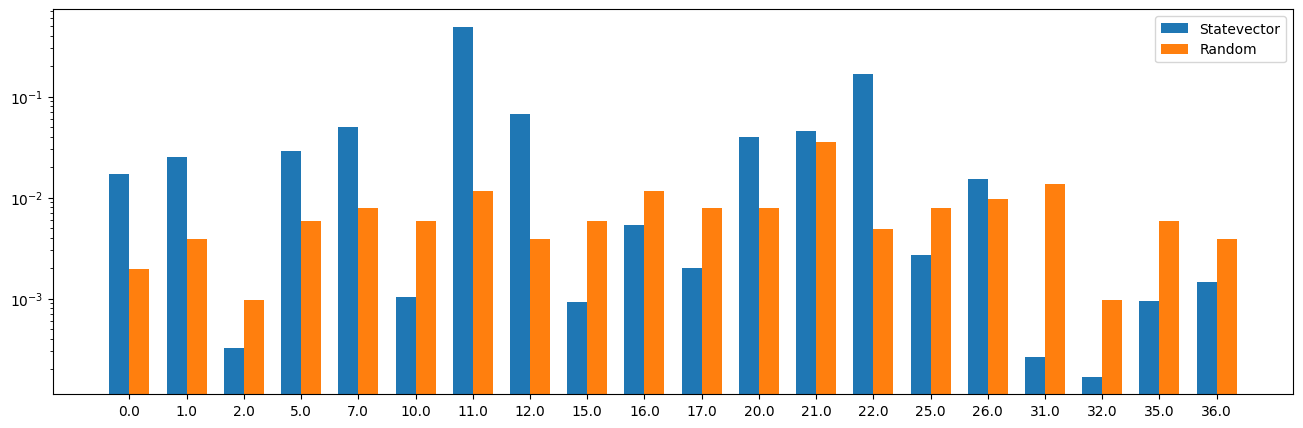

In [9]:
plot_sv_bars(evals, sv)

In [10]:
p = 3
n=4096
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/cvar_new/hardware/{filename}_sample.p{p}.shots{n}.initwarm.pkl', 'rb') as f:
    res = pickle.load(f)

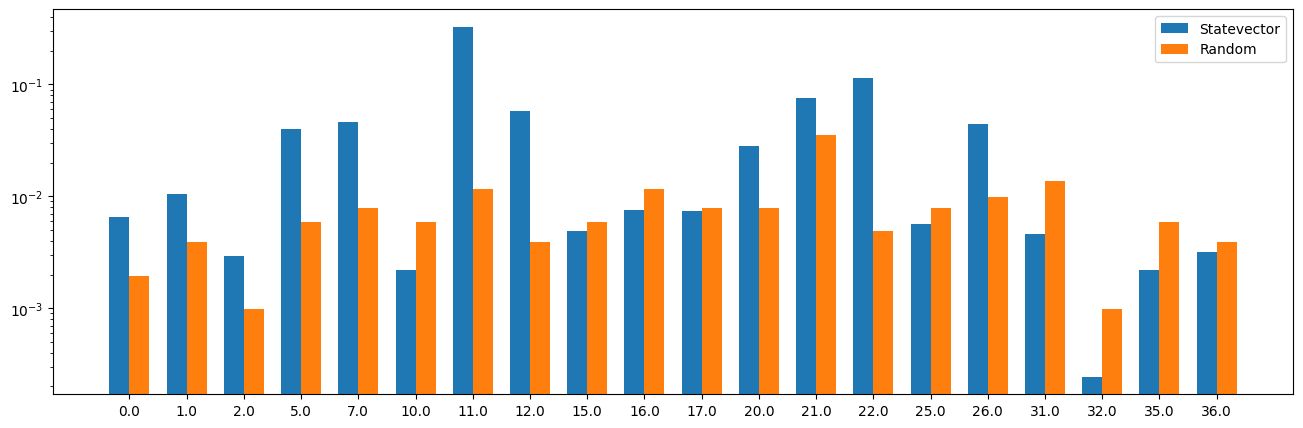

In [11]:
_, ax = plt.subplots(1,1,figsize=(16, 5))
counter = Counter(evals)
evals_set = list(set(evals))
labels = evals_set

bars = {eval: 0 for eval in evals_set}
for label, count in res['counts'].items():
    bars[evals[int(label, 2)]] += count / n
sv_bars = np.array(list(bars.values()))
random_bars = np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

cutoff = 20
ax.bar(x[:cutoff] - width/2, sv_bars[:cutoff], width, label='Statevector')
ax.bar(x[:cutoff] + width/2, random_bars[:cutoff], width, label='Random')
ax.set_xticks(x[:cutoff])
ax.set_xticklabels(labels[:cutoff])
ax.set_yscale('log')
ax.legend()

In [15]:
p = 3
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/cvar_new/{filename}.sweep.p{p}.no_shot_noise.pkl', 'rb') as f:
    res = pickle.load(f)
sim_sv = res['best_sv']


n=4096
with open(f'/lustre/scratch127/qpg/jc59/out/qiskit/cvar_new/hardware/{filename}_sample.p{p}.shots{n}.initwarm.pkl', 'rb') as f:
    res = pickle.load(f)
counts = res['counts']

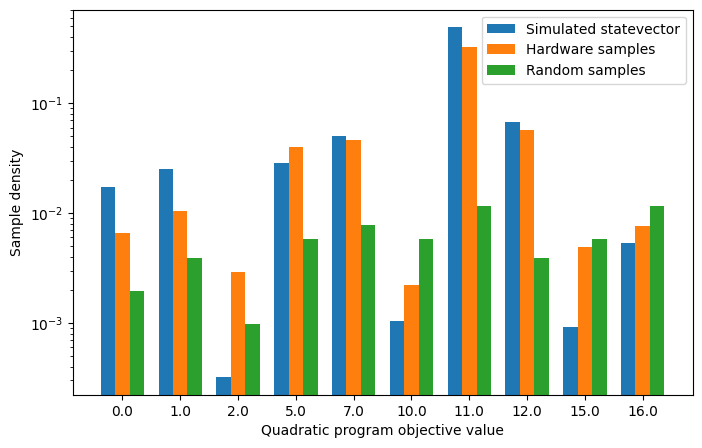

In [18]:
_, ax = plt.subplots(1,1,figsize=(8, 5))
counter = Counter(evals)
evals_set = list(set(evals))
labels = evals_set

bars = {eval: 0 for eval in evals_set}
for label, count in counts.items():
    bars[evals[int(label, 2)]] += count / n
hardware_sample_bars = np.array(list(bars.values()))



evals_set = list(set(evals))
bars = {eval: 0 for eval in evals_set}
for x in range(len(sim_sv)):
    bars[evals[x]] += np.abs(sim_sv[x]) ** 2
sim_sv_bars = np.array(list(bars.values()))


random_bars = np.array([counter[eval] for eval in sorted(evals_set)]) / 2**num_qubits


x = np.arange(len(labels))  # the label locations
width = 0.25  # the width of the bars

cutoff = 10
ax.bar(x[:cutoff] - width, sim_sv_bars[:cutoff], width, label='Simulated statevector')
ax.bar(x[:cutoff], hardware_sample_bars[:cutoff], width, label='Hardware samples')
ax.bar(x[:cutoff] + width, random_bars[:cutoff], width, label='Random samples')
ax.set_xticks(x[:cutoff])
ax.set_xticklabels(labels[:cutoff])
ax.set_yscale('log')

ax.set_xlabel('Quadratic program objective value')
ax.set_ylabel('Sample density')
ax.legend()

In [20]:
sim_sv_bars[0] / random_bars[0], hardware_sample_bars[0] / random_bars[0], random_bars[0]

(np.float64(8.795718110448359), np.float64(3.375), np.float64(0.001953125))